In [ ]:
import zipfile

zip_path = "/content/tiny-imagenet.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")


Extraction done!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])


In [ ]:
train_dataset = datasets.ImageFolder("data/train", transform=transform)
val_dataset   = datasets.ImageFolder("data/val", transform=transform)
test_dataset  = datasets.ImageFolder("data/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)


Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']


In [ ]:

class DeepCNN_NoBN(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepCNN_NoBN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv5 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv6 = nn.Conv2d(256, 256, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(256 * 8 * 8, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.pool(F.relu(self.conv4(x)))

        x = self.conv5(x)

        self.activations_5 = x.detach()

        x = F.relu(x)
        x = self.pool(F.relu(self.conv6(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
class DeepCNN_BN(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepCNN_BN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        self.conv6 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(256 * 8 * 8, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = self.conv5(x)
        x = self.bn5(x)

        self.activations_5 = x.detach()

        x = F.relu(x)

        x = self.pool(F.relu(self.bn6(self.conv6(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
def train_model(model, epochs, track_activations=False):
    model.to(device)
    train_losses, val_losses = [], []

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    max_batches = 500
    batch_count = 0

    act_means, act_vars = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if track_activations and batch_count < max_batches:
                act = model.activations_5
                act_means.append(act.mean().item())
                act_vars.append(act.var(unbiased=False).item())
                batch_count += 1

        train_losses.append(running_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")

    return train_losses, val_losses, act_means, act_vars


In [ ]:
model_no_bn = DeepCNN_NoBN(num_classes)
train_loss_A, val_loss_A, mean_no_bn, var_no_bn = train_model(
    model_no_bn, epochs=10, track_activations=True
)


Epoch 1: Train Loss=1.9692, Val Loss=1.8052
Epoch 2: Train Loss=1.7295, Val Loss=1.7542
Epoch 3: Train Loss=1.6723, Val Loss=1.6755
Epoch 4: Train Loss=1.5668, Val Loss=1.5958
Epoch 5: Train Loss=1.4437, Val Loss=1.4341
Epoch 6: Train Loss=1.3454, Val Loss=1.4345
Epoch 7: Train Loss=1.2298, Val Loss=1.2812
Epoch 8: Train Loss=1.1744, Val Loss=1.2845
Epoch 9: Train Loss=1.0732, Val Loss=1.3788
Epoch 10: Train Loss=0.9976, Val Loss=1.2512


In [ ]:
model_bn = DeepCNN_BN(num_classes)
train_loss_B, val_loss_B, mean_bn, var_bn = train_model(
    model_bn, epochs=10, track_activations=True
)


Epoch 1: Train Loss=2.9515, Val Loss=1.6912
Epoch 2: Train Loss=1.7130, Val Loss=2.0715
Epoch 3: Train Loss=1.4967, Val Loss=1.4198
Epoch 4: Train Loss=1.3743, Val Loss=1.4782
Epoch 5: Train Loss=1.3234, Val Loss=1.5111
Epoch 6: Train Loss=1.2958, Val Loss=1.3334
Epoch 7: Train Loss=1.1861, Val Loss=1.3181
Epoch 8: Train Loss=1.1500, Val Loss=1.3095
Epoch 9: Train Loss=1.0655, Val Loss=1.2613
Epoch 10: Train Loss=1.0416, Val Loss=1.3705


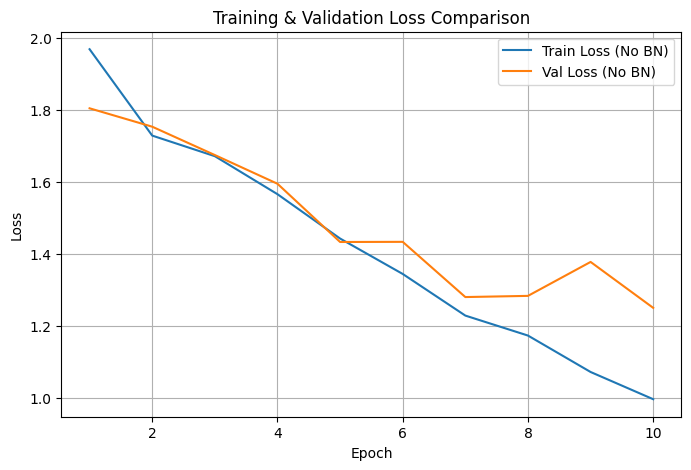

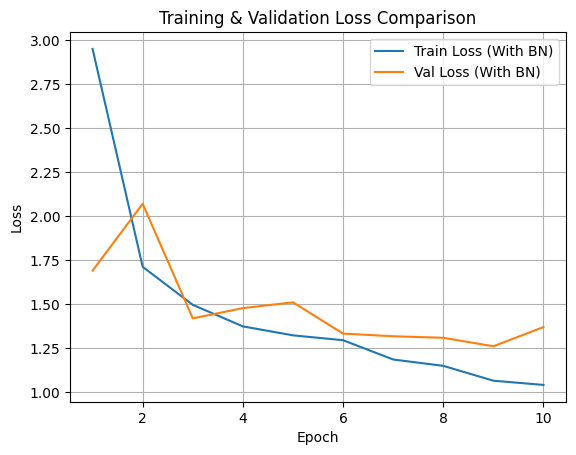

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_A) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss_A, label='Train Loss (No BN)')
plt.plot(epochs, val_loss_A, label='Val Loss (No BN)')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()
epochs = range(1, len(train_loss_B) + 1)
plt.plot(epochs, train_loss_B, label='Train Loss (With BN)')
plt.plot(epochs, val_loss_B, label='Val Loss (With BN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()

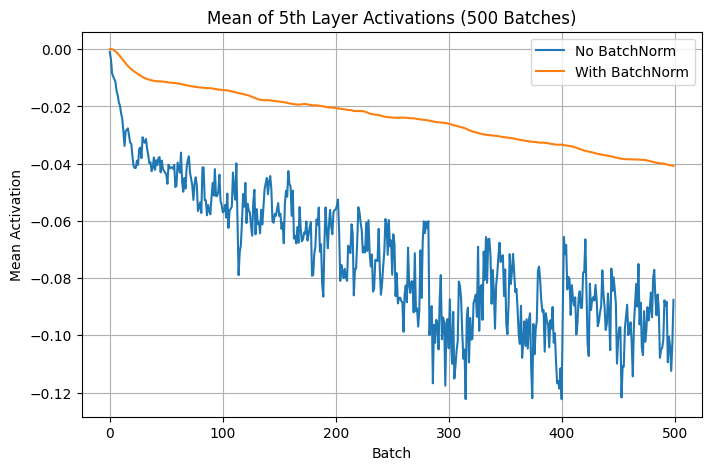

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(mean_no_bn, label='No BatchNorm')
plt.plot(mean_bn, label='With BatchNorm')
plt.xlabel('Batch')
plt.ylabel('Mean Activation')
plt.title('Mean of 5th Layer Activations (500 Batches)')
plt.legend()
plt.grid(True)
plt.show()


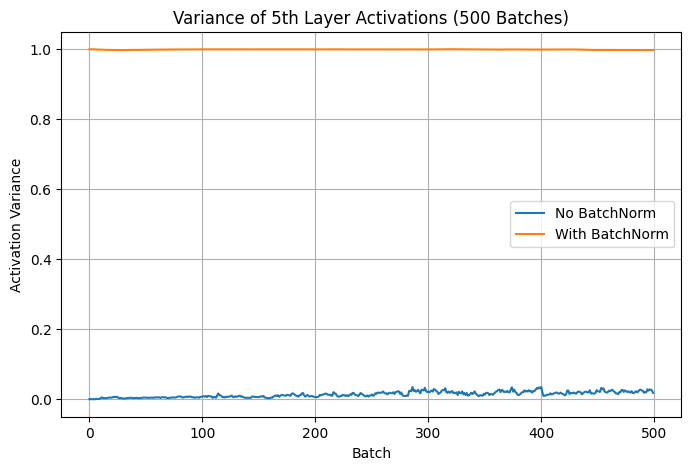

[0.9999389052391052, 0.9999163150787354, 0.9998353123664856, 0.9997344613075256, 0.99954754114151, 0.9993917346000671, 0.9992216229438782, 0.999076783657074, 0.9989283680915833, 0.9987731575965881, 0.9986217021942139, 0.9984704256057739, 0.9983283281326294, 0.9982004761695862, 0.9980941414833069, 0.9980147480964661, 0.9979475736618042, 0.9978864789009094, 0.9978269338607788, 0.9977778196334839, 0.9977416396141052, 0.9977169036865234, 0.9976925253868103, 0.9976565837860107, 0.9976169466972351, 0.9975817799568176, 0.997550368309021, 0.9975250959396362, 0.9974982738494873, 0.9974943399429321, 0.9975074529647827, 0.9975202083587646, 0.997541606426239, 0.9975799322128296, 0.9976344704627991, 0.997691810131073, 0.9977468252182007, 0.9978010058403015, 0.9978511333465576, 0.9978893399238586, 0.9979284405708313, 0.9979702830314636, 0.9980049729347229, 0.9980522394180298, 0.9981001019477844, 0.9981354475021362, 0.9981829524040222, 0.9982134103775024, 0.9982524514198303, 0.9982993006706238, 0.998

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(var_no_bn, label='No BatchNorm')
plt.plot(var_bn, label='With BatchNorm')
plt.xlabel('Batch')
plt.ylabel('Activation Variance')
plt.title('Variance of 5th Layer Activations (500 Batches)')
plt.legend()
plt.grid(True)
plt.show()
print(var_bn)
print(var_no_bn)

In [ ]:

torch.save(model_no_bn.state_dict(), "deepcnn_no_bn.pth")

torch.save(model_bn.state_dict(), "deepcnn_bn.pth")


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, dataloader, device, model_name="Model"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"\n{model_name} Performance on Test Set")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return acc, precision, recall, f1


In [ ]:

evaluate_model(
    model_no_bn,
    test_loader,
    device,
    model_name="CNN WITHOUT BatchNorm"
)


evaluate_model(
    model_bn,
    test_loader,
    device,
    model_name="CNN WITH BatchNorm"
)



CNN WITHOUT BatchNorm Performance on Test Set
Accuracy  : 0.5230
Precision : 0.5295
Recall    : 0.5230
F1 Score  : 0.5167

CNN WITH BatchNorm Performance on Test Set
Accuracy  : 0.5970
Precision : 0.6254
Recall    : 0.5970
F1 Score  : 0.5850


(0.597, 0.6254224746082688, 0.597, 0.5849524856147135)